# QAOA-ISAC Training Notebook

This notebook is simulation-only. It resumes the structure of the original UAV/QAOA notebook, but focuses on training QAOA cleanly before any IBM Quantum hardware work.

Run this notebook from top to bottom. Do not add hardware cells here; hardware submission will be added later after the simulation evidence is clear.

## 1. System Model

We place `U` UAVs on `G` candidate 3-D grid points to serve `S` ground survivors.

Objective:

```text
maximize total rate = sum_s B log2(1 + SINR_s)
```

Constraints:

```text
C1: each UAV chooses exactly one grid point
C2: no two UAVs occupy the same grid point
C3: every survivor satisfies the minimum SINR threshold
C4: UAVs avoid unsafe collision pairs
```

The main QAOA here is valid-subspace QAOA: basis states are feasible UAV assignments, the phase separator uses exact sum-rate, and the mixer connects feasible assignments that differ by one UAV relocation.

## 2. Imports

In [1]:
from pathlib import Path
import importlib
import json
import math

import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except Exception:
    pd = None

from IPython.display import Markdown, display

import qaoa_isac_benchmark as benchmark
import qaoa_isac_env as env_module

importlib.invalidate_caches()
benchmark = importlib.reload(benchmark)
env_module = importlib.reload(env_module)

SystemParams = env_module.SystemParams
build_environment = benchmark.build_environment
enumerate_assignments = benchmark.enumerate_assignments
greedy_assignment = benchmark.greedy_assignment
local_search = benchmark.local_search
run_valid_subspace_qaoa = benchmark.run_valid_subspace_qaoa
compare_qaoa_vs_random_local_search = benchmark.compare_qaoa_vs_random_local_search
compare_simulated_annealing = benchmark.compare_simulated_annealing
build_top_k_sweep = benchmark.build_top_k_sweep

## 3. Training Configuration

Two scenarios are trained:

- **Headline:** `U=4, G=6, S=6`, the main exact-validated showcase.
- **Scale:** `U=4, G=7, S=7`, a larger exact-valid-subspace challenge.

For each scenario, we train two p=1 QAOA variants:

- `expected_rate`: chooses angles that maximize expected sum-rate.
- `top_k_raw_rate`: chooses angles whose top-K probability-ranked candidates contain the best raw sum-rate. This matches how we actually use QAOA as a candidate generator.

In [2]:
SCENARIOS = {
    "headline": {
        "params": SystemParams(U=4, G=6, S=6, Nt=4, Gamma_min=0.5),
        "seed": 67,
        "grid_steps": 81,
        "top_k": 8,
        "random_trials": 64,
        "sa_trials": 32,
    },
    "scale": {
        "params": SystemParams(U=4, G=7, S=7, Nt=4, Gamma_min=0.5),
        "seed": 8,
        "grid_steps": 31,
        "top_k": 8,
        "random_trials": 32,
        "sa_trials": 16,
    },
}

TOP_K_SWEEP = [1, 2, 4, 8, 16]
SHOTS = 1024
OUTPUT_JSON = Path("qaoa_isac_training_results.json")

## 4. Training Helpers

In [3]:
def ar(row, exact):
    return row.sum_rate / exact.sum_rate


def train_scenario(name, cfg):
    env = build_environment(cfg["params"], seed=cfg["seed"], quiet=True)
    feasible = enumerate_assignments(env, require_c3=True)
    if len(feasible) < 2:
        raise RuntimeError(f"{name}: fewer than two feasible assignments")

    exact_index, exact = max(enumerate(feasible), key=lambda item: item[1].sum_rate)
    greedy = greedy_assignment(env)
    greedy_polished = local_search(env, greedy)

    expected_result, expected_probs = run_valid_subspace_qaoa(
        feasible,
        exact_index,
        reps=1,
        grid_steps=cfg["grid_steps"],
        shots=SHOTS,
        seed=cfg["seed"],
        record_diagnostics=True,
        selection_objective="expected_rate",
        candidate_top_k=cfg["top_k"],
    )
    candidate_result, candidate_probs = run_valid_subspace_qaoa(
        feasible,
        exact_index,
        reps=1,
        grid_steps=cfg["grid_steps"],
        shots=SHOTS,
        seed=cfg["seed"],
        record_diagnostics=True,
        selection_objective="top_k_raw_rate",
        candidate_top_k=cfg["top_k"],
    )

    expected_local = compare_qaoa_vs_random_local_search(
        env, feasible, expected_probs, exact,
        top_k=cfg["top_k"], random_trials=cfg["random_trials"], seed=cfg["seed"],
    )
    candidate_local = compare_qaoa_vs_random_local_search(
        env, feasible, candidate_probs, exact,
        top_k=cfg["top_k"], random_trials=cfg["random_trials"], seed=cfg["seed"] + 17,
    )
    sa = compare_simulated_annealing(
        feasible, exact,
        restarts=cfg["top_k"], steps_per_restart=24, trials=cfg["sa_trials"], seed=cfg["seed"],
    )

    expected_sweep = build_top_k_sweep(
        env, feasible, expected_probs, exact,
        top_k_values=TOP_K_SWEEP, random_trials=cfg["random_trials"], seed=cfg["seed"],
    )
    candidate_sweep = []
    for k in TOP_K_SWEEP:
        effective_k = min(k, len(feasible))
        comparison = compare_qaoa_vs_random_local_search(
            env, feasible, candidate_probs, exact,
            top_k=effective_k, random_trials=cfg["random_trials"], seed=cfg["seed"] + 1000 + k,
        )
        candidate_sweep.append({
            "top_k": k,
            "effective_top_k": effective_k,
            "qaoa_raw_AR_rate": comparison.qaoa_raw_best.sum_rate / exact.sum_rate,
            "qaoa_AR_rate": comparison.qaoa_best.sum_rate / exact.sum_rate,
            "random_mean_AR_rate": comparison.random_mean_ar,
            "qaoa_gain_over_random_mean": comparison.qaoa_best.sum_rate / exact.sum_rate - comparison.random_mean_ar,
            "random_optimum_hit_rate": comparison.random_optimum_hit_rate,
        })

    return {
        "name": name,
        "env": env,
        "feasible": feasible,
        "exact_index": exact_index,
        "exact": exact,
        "greedy": greedy,
        "greedy_local": greedy_polished,
        "expected_result": expected_result,
        "expected_probs": expected_probs,
        "candidate_result": candidate_result,
        "candidate_probs": candidate_probs,
        "expected_local": expected_local,
        "candidate_local": candidate_local,
        "simulated_annealing": sa,
        "expected_sweep": expected_sweep,
        "candidate_sweep": candidate_sweep,
    }


def result_summary(case):
    exact = case["exact"]
    expected_top = case["feasible"][case["expected_result"].top_index]
    candidate_top = case["feasible"][case["candidate_result"].top_index]
    return [
        {"scenario": case["name"], "method": "Greedy", "AR": ar(case["greedy"], exact), "note": "baseline"},
        {"scenario": case["name"], "method": "Greedy + local", "AR": ar(case["greedy_local"], exact), "note": "baseline"},
        {"scenario": case["name"], "method": "Expected-rate QAOA top", "AR": ar(expected_top, exact), "note": "trained for expectation"},
        {"scenario": case["name"], "method": "Expected-rate QAOA top-K + local", "AR": ar(case["expected_local"].qaoa_best, exact), "note": "candidate generator"},
        {"scenario": case["name"], "method": "Candidate-aware QAOA top", "AR": ar(candidate_top, exact), "note": "trained for top-K quality"},
        {"scenario": case["name"], "method": "Candidate-aware QAOA top-K + local", "AR": ar(case["candidate_local"].qaoa_best, exact), "note": "candidate generator"},
        {"scenario": case["name"], "method": "Simulated annealing mean", "AR": case["simulated_annealing"].mean_ar, "note": "strong classical baseline"},
    ]

## 5. Train QAOA

This cell is the actual QAOA training. It grid-searches `gamma` and `beta` in simulation. The scale scenario is slower than the headline scenario.

In [4]:
training_cases = {}
for name, cfg in SCENARIOS.items():
    print(f"Training {name}: U={cfg['params'].U}, G={cfg['params'].G}, S={cfg['params'].S}, grid_steps={cfg['grid_steps']}")
    training_cases[name] = train_scenario(name, cfg)
    case = training_cases[name]
    print(
        f"  feasible={len(case['feasible'])}, exact={case['exact'].sum_rate / 1e6:.3f} Mbps, "
        f"expected-QAOA raw top-{cfg['top_k']} AR={ar(case['expected_local'].qaoa_raw_best, case['exact']):.3f}, "
        f"candidate-aware raw top-{cfg['top_k']} AR={ar(case['candidate_local'].qaoa_raw_best, case['exact']):.3f}"
    )

Training headline: U=4, G=6, S=6, grid_steps=81
  feasible=329, exact=7.627 Mbps, expected-QAOA raw top-8 AR=1.000, candidate-aware raw top-8 AR=1.000
Training scale: U=4, G=7, S=7, grid_steps=31
  feasible=724, exact=10.724 Mbps, expected-QAOA raw top-8 AR=0.927, candidate-aware raw top-8 AR=1.000


## 5.1 Training Convergence

These plots show the QAOA angle-search convergence immediately after training. The left plot tracks the expected-rate objective; the right plot tracks top-K candidate quality, which is the objective used by the improved candidate-aware QAOA run.


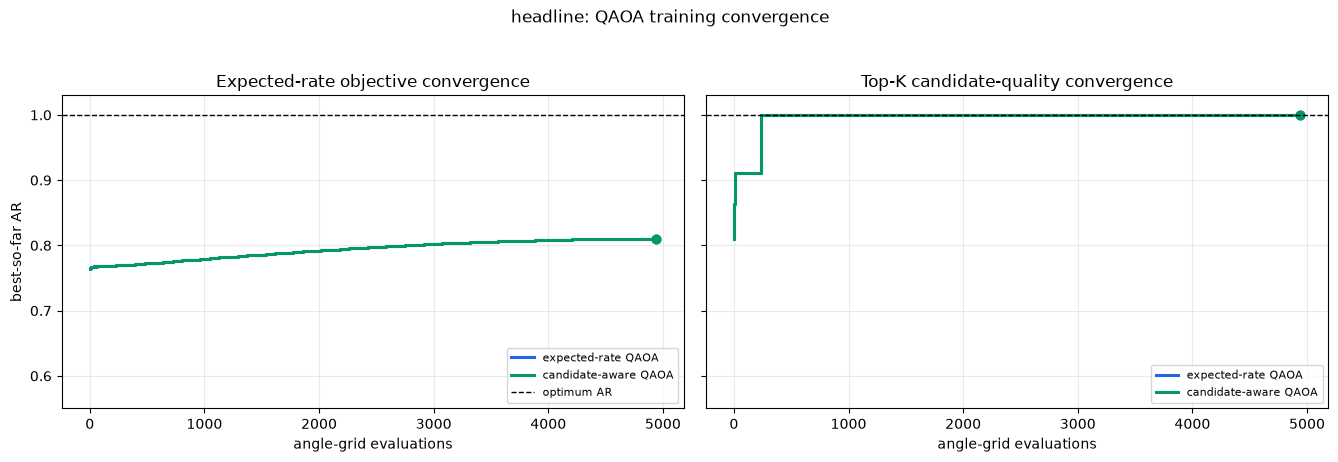

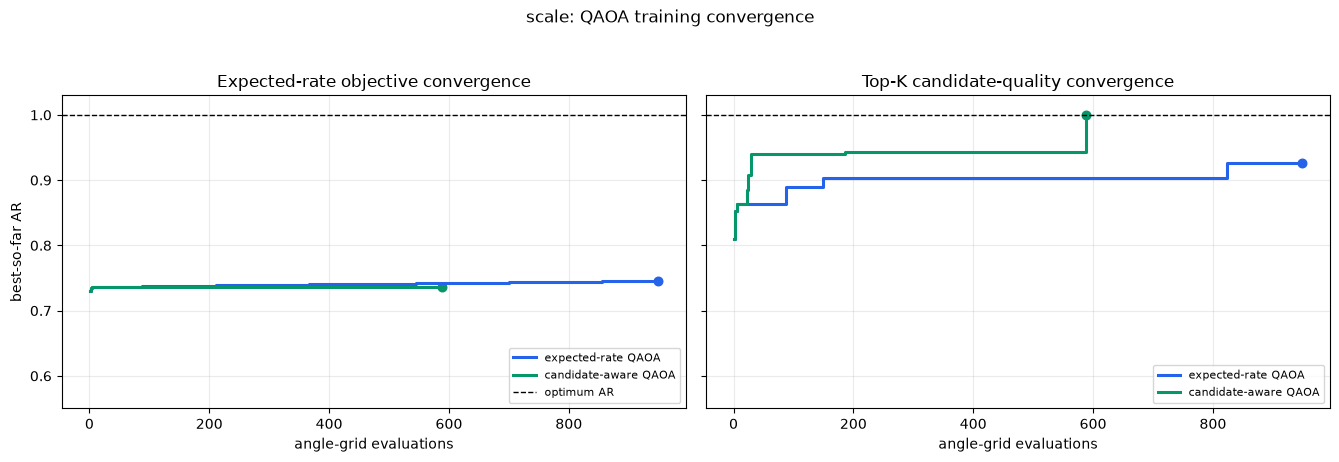

In [5]:
# Standalone convergence figures for simulation training.

def _best_trace_xy(result, metric_key):
    trace = list(result.best_so_far_trace)
    if not trace:
        return [], []
    xs = [int(row["evaluation"]) for row in trace]
    ys = [float(row.get(metric_key, row.get("top_AR_rate", np.nan))) for row in trace]
    return xs, list(np.maximum.accumulate(ys))


def plot_training_convergence(case):
    runs = [
        ("expected-rate QAOA", case["expected_result"], "#2563eb"),
        ("candidate-aware QAOA", case["candidate_result"], "#059669"),
    ]
    metrics = [
        ("best_expected_AR_rate", "Expected-rate objective convergence"),
        ("top_k_raw_AR_rate", "Top-K candidate-quality convergence"),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4), sharey=True)
    for ax, (metric_key, title) in zip(axes, metrics):
        for label, result, color in runs:
            xs, ys = _best_trace_xy(result, metric_key)
            if xs:
                ax.step(xs, ys, where="post", label=label, color=color, linewidth=2.2)
                ax.scatter([xs[-1]], [ys[-1]], color=color, s=38)
        ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="optimum AR" if metric_key == metrics[0][0] else None)
        ax.set_title(title)
        ax.set_xlabel("angle-grid evaluations")
        ax.set_ylim(0.55, 1.03)
        ax.grid(alpha=0.25)
    axes[0].set_ylabel("best-so-far AR")
    axes[0].legend(fontsize=8, loc="lower right")
    axes[1].legend(fontsize=8, loc="lower right")
    fig.suptitle(f"{case['name']}: QAOA training convergence", y=1.04)
    fig.tight_layout()
    plt.show()


for case in training_cases.values():
    plot_training_convergence(case)


## 6. Final Scorecard

In [6]:
score_rows = []
for case in training_cases.values():
    score_rows.extend(result_summary(case))

if pd is not None:
    display(pd.DataFrame(score_rows))
else:
    print(json.dumps(score_rows, indent=2))

for name, case in training_cases.items():
    exact = case["exact"]
    expected = case["expected_result"]
    candidate = case["candidate_result"]
    print(f"\n{name.upper()} training angles")
    print(f"  expected-rate: gamma={expected.gamma:.6f}, beta={expected.beta:.6f}, opt_p={expected.optimum_probability:.6f}")
    print(f"  candidate-aware: gamma={candidate.gamma:.6f}, beta={candidate.beta:.6f}, opt_p={candidate.optimum_probability:.6f}")
    print(f"  expected raw top-K AR={ar(case['expected_local'].qaoa_raw_best, exact):.3f}; local AR={ar(case['expected_local'].qaoa_best, exact):.3f}")
    print(f"  candidate raw top-K AR={ar(case['candidate_local'].qaoa_raw_best, exact):.3f}; local AR={ar(case['candidate_local'].qaoa_best, exact):.3f}")

,scenario,method,AR,note
0,headline,Greedy,0.811145,baseline
1,headline,Greedy + local,0.811145,baseline
2,headline,Expected-rate QAOA top,1.000000,trained for expectation
3,headline,Expected-rate QAOA top-K + local,1.000000,candidate generator
4,headline,Candidate-aware QAOA top,1.000000,trained for top-K quality
5,headline,Candidate-aware QAOA top-K + local,1.000000,candidate generator
6,headline,Simulated annealing mean,0.992947,strong classical baseline
7,scale,Greedy,0.818709,baseline
8,scale,Greedy + local,0.834588,baseline
9,scale,Expected-rate QAOA top,0.903137,trained for expectation



HEADLINE training angles
  expected-rate: gamma=4.712389, beta=2.984513, opt_p=0.018982
  candidate-aware: gamma=4.712389, beta=2.984513, opt_p=0.018982
  expected raw top-K AR=1.000; local AR=1.000
  candidate raw top-K AR=1.000; local AR=1.000

SCALE training angles
  expected-rate: gamma=6.283185, beta=1.780236, opt_p=0.001167
  candidate-aware: gamma=3.769911, beta=3.141593, opt_p=0.004048
  expected raw top-K AR=0.927; local AR=1.000
  candidate raw top-K AR=1.000; local AR=1.000


## 7. Figures: System Model, Training, and Candidate Efficiency

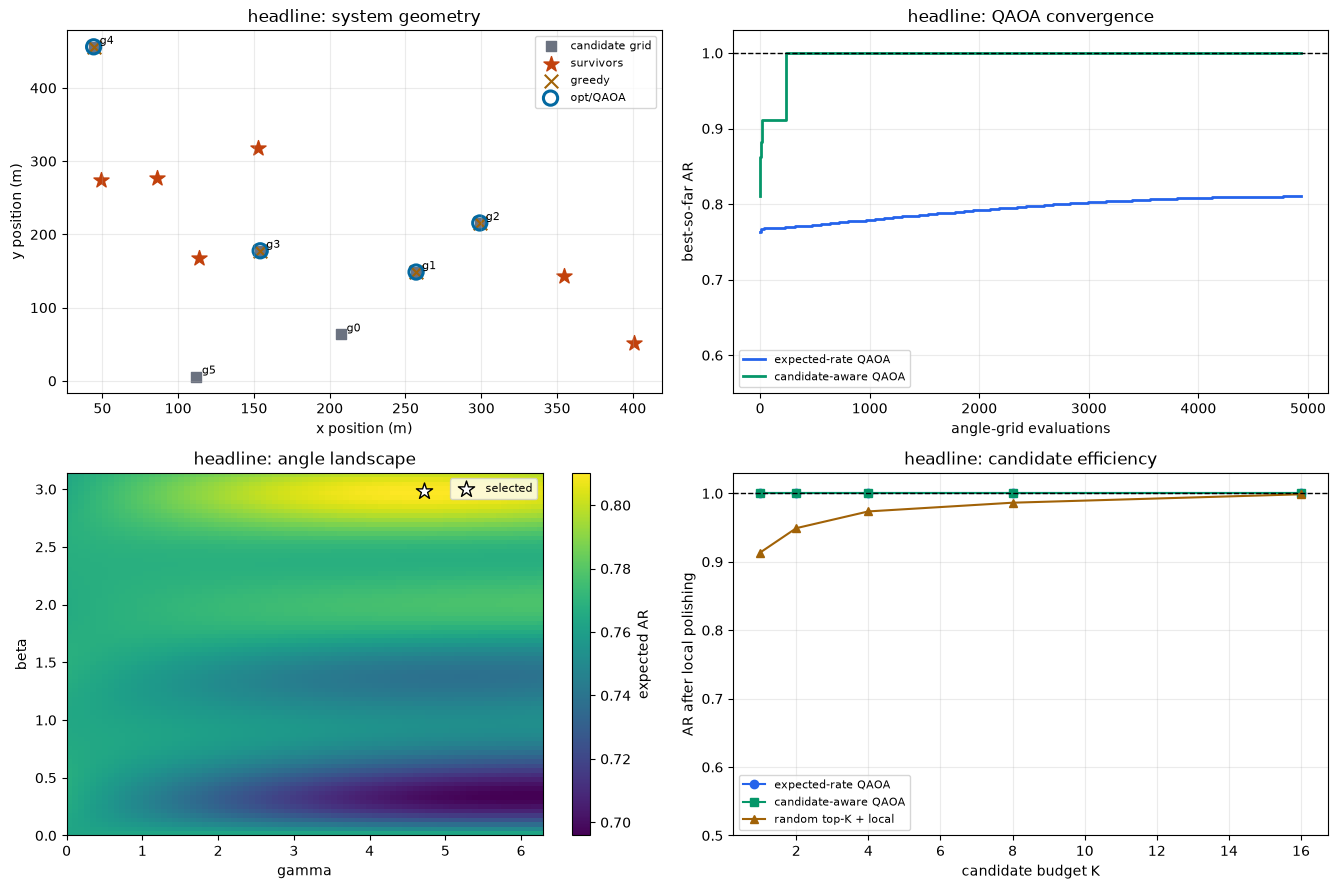

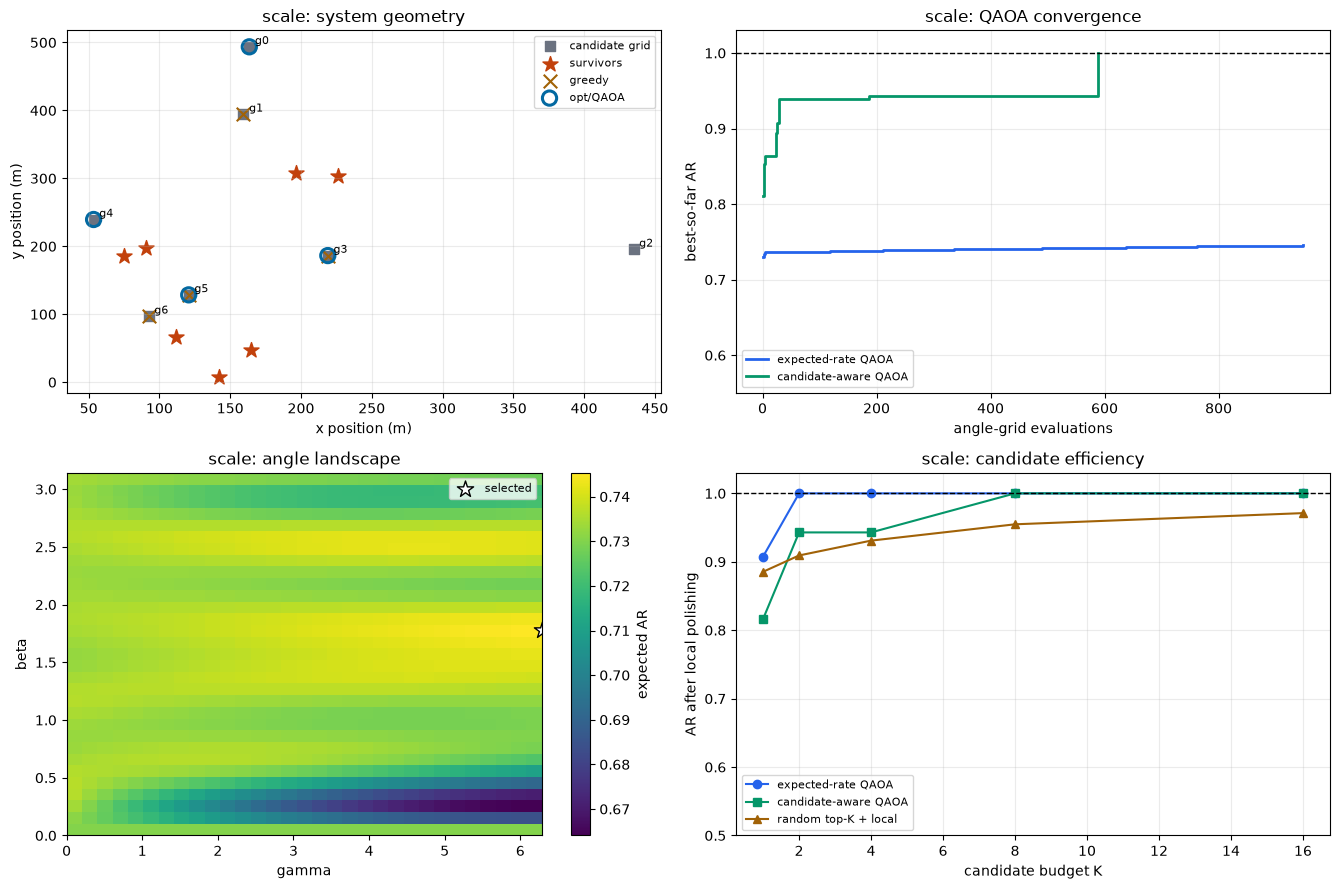

In [7]:
def plot_system(case, ax):
    env = case["env"]
    exact = case["exact"]
    greedy = case["greedy"]
    grid = env.p_grid
    survivors = env.q_surv
    ax.scatter(grid[:, 0], grid[:, 1], marker="s", s=60, color="#6b7280", label="candidate grid")
    ax.scatter(survivors[:, 0], survivors[:, 1], marker="*", s=130, color="#c2410c", label="survivors")
    exact_points = grid[list(exact.assignment)]
    greedy_points = grid[list(greedy.assignment)]
    ax.scatter(greedy_points[:, 0], greedy_points[:, 1], marker="x", s=95, color="#a16207", label="greedy")
    ax.scatter(exact_points[:, 0], exact_points[:, 1], marker="o", s=105, facecolor="none", edgecolor="#0369a1", linewidth=2.2, label="opt/QAOA")
    for idx, point in enumerate(grid):
        ax.text(point[0] + 4, point[1] + 4, f"g{idx}", fontsize=8)
    ax.set_title(f"{case['name']}: system geometry")
    ax.set_xlabel("x position (m)")
    ax.set_ylabel("y position (m)")
    ax.grid(alpha=0.25)
    ax.legend(loc="best", fontsize=8)


def plot_training_trace(case, ax):
    runs = [
        ("expected-rate QAOA", case["expected_result"], "best_expected_AR_rate", "#2563eb"),
        ("candidate-aware QAOA", case["candidate_result"], "top_k_raw_AR_rate", "#059669"),
    ]
    drew_any = False
    for label, result, metric_key, color in runs:
        trace = list(result.best_so_far_trace)
        if not trace:
            continue
        evaluations = [row["evaluation"] for row in trace]
        values = [float(row.get(metric_key, row.get("top_AR_rate", np.nan))) for row in trace]
        ax.step(evaluations, np.maximum.accumulate(values), where="post", label=label, color=color, linewidth=2.0)
        drew_any = True
    if not drew_any:
        ax.text(0.5, 0.5, "No trace recorded", ha="center")
        return
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{case['name']}: QAOA convergence")
    ax.set_xlabel("angle-grid evaluations")
    ax.set_ylabel("best-so-far AR")
    ax.set_ylim(0.55, 1.03)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)


def plot_angle_landscape(case, ax):
    qaoa = case["expected_result"]
    landscape = np.array(qaoa.angle_landscape, dtype=float)
    image = ax.imshow(
        landscape.T,
        origin="lower",
        aspect="auto",
        extent=[min(qaoa.gamma_grid), max(qaoa.gamma_grid), min(qaoa.beta_grid), max(qaoa.beta_grid)],
        cmap="viridis",
    )
    ax.scatter([qaoa.gamma], [qaoa.beta], marker="*", s=150, color="white", edgecolor="black", label="selected")
    ax.set_title(f"{case['name']}: angle landscape")
    ax.set_xlabel("gamma")
    ax.set_ylabel("beta")
    ax.legend(fontsize=8)
    return image


def plot_candidate_efficiency(case, ax):
    expected = case["expected_sweep"]
    candidate = case["candidate_sweep"]
    k = [row["top_k"] for row in expected]
    ax.plot(k, [row["qaoa_AR_rate"] for row in expected], marker="o", label="expected-rate QAOA", color="#2563eb")
    ax.plot(k, [row["qaoa_AR_rate"] for row in candidate], marker="s", label="candidate-aware QAOA", color="#059669")
    ax.plot(k, [row["random_mean_AR_rate"] for row in expected], marker="^", label="random top-K + local", color="#a16207")
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{case['name']}: candidate efficiency")
    ax.set_xlabel("candidate budget K")
    ax.set_ylabel("AR after local polishing")
    ax.set_ylim(0.5, 1.03)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

for case in training_cases.values():
    fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.0))
    plot_system(case, axes[0, 0])
    plot_training_trace(case, axes[0, 1])
    image = plot_angle_landscape(case, axes[1, 0])
    fig.colorbar(image, ax=axes[1, 0], label="expected AR")
    plot_candidate_efficiency(case, axes[1, 1])
    fig.tight_layout()
    plt.show()


## 8. What This Proves

In [8]:
display(Markdown("""
### Claim To Use

The main method is a valid-subspace QAOA candidate generator for constrained ISAC UAV deployment.
It trains QAOA angles in simulation, ranks feasible UAV assignments by probability, and polishes only the top-K candidates with local search.

### Why This Is Stronger Than The Old Notebook

- The system model is explicit: SINR/rate objective plus assignment, no-colocation, SINR, and collision constraints.
- QAOA training is explicit: `gamma` and `beta` are grid-searched in simulation.
- The candidate-aware training objective matches how the algorithm is actually used.
- Hardware is intentionally excluded from this notebook; IBM hardware execution will be added later as a separate validation path.

### Do Not Claim

Do not claim hardware-trained QAOA here. This notebook trains QAOA in simulation only.
"""))


### Claim To Use

The main method is a valid-subspace QAOA candidate generator for constrained ISAC UAV deployment.
It trains QAOA angles in simulation, ranks feasible UAV assignments by probability, and polishes only the top-K candidates with local search.

### Why This Is Stronger Than The Old Notebook

- The system model is explicit: SINR/rate objective plus assignment, no-colocation, SINR, and collision constraints.
- QAOA training is explicit: `gamma` and `beta` are grid-searched in simulation.
- The candidate-aware training objective matches how the algorithm is actually used.
- Hardware is intentionally excluded from this notebook; IBM hardware execution will be added later as a separate validation path.

### Do Not Claim

Do not claim hardware-trained QAOA here. This notebook trains QAOA in simulation only.


## 9. Export Simulation Training Evidence

In [9]:
def serialize_case(case):
    exact = case["exact"]
    return {
        "scenario": {
            "name": case["name"],
            "U": case["env"].params.U,
            "G": case["env"].params.G,
            "S": case["env"].params.S,
            "Nt": case["env"].params.Nt,
            "Gamma_min": case["env"].params.Gamma_min,
            "feasible_assignment_count": len(case["feasible"]),
        },
        "exact": exact.to_json(exact.sum_rate),
        "greedy_AR_rate": ar(case["greedy"], exact),
        "greedy_local_AR_rate": ar(case["greedy_local"], exact),
        "expected_rate_qaoa": {
            "gamma": case["expected_result"].gamma,
            "beta": case["expected_result"].beta,
            "expected_AR_rate": case["expected_result"].expected_rate / exact.sum_rate,
            "top_AR_rate": ar(case["feasible"][case["expected_result"].top_index], exact),
            "raw_top_k_AR_rate": ar(case["expected_local"].qaoa_raw_best, exact),
            "top_k_local_AR_rate": ar(case["expected_local"].qaoa_best, exact),
            "optimum_probability": case["expected_result"].optimum_probability,
        },
        "candidate_aware_qaoa": {
            "gamma": case["candidate_result"].gamma,
            "beta": case["candidate_result"].beta,
            "expected_AR_rate": case["candidate_result"].expected_rate / exact.sum_rate,
            "top_AR_rate": ar(case["feasible"][case["candidate_result"].top_index], exact),
            "raw_top_k_AR_rate": ar(case["candidate_local"].qaoa_raw_best, exact),
            "top_k_local_AR_rate": ar(case["candidate_local"].qaoa_best, exact),
            "optimum_probability": case["candidate_result"].optimum_probability,
        },
        "simulated_annealing_mean_AR_rate": case["simulated_annealing"].mean_ar,
        "expected_top_k_sweep": case["expected_sweep"],
        "candidate_top_k_sweep": case["candidate_sweep"],
    }

training_payload = {
    "purpose": "Simulation-only QAOA training evidence for ISAC UAV deployment.",
    "hardware_included": False,
    "cases": {name: serialize_case(case) for name, case in training_cases.items()},
}

OUTPUT_JSON.write_text(json.dumps(training_payload, indent=2), encoding="utf-8")
print(f"Saved {OUTPUT_JSON}")
print(json.dumps({name: training_payload["cases"][name]["candidate_aware_qaoa"] for name in training_payload["cases"]}, indent=2))

Saved qaoa_isac_training_results.json
{
  "headline": {
    "gamma": 4.71238898038469,
    "beta": 2.9845130209103035,
    "expected_AR_rate": 0.8102071450680116,
    "top_AR_rate": 1.0,
    "raw_top_k_AR_rate": 1.0,
    "top_k_local_AR_rate": 1.0,
    "optimum_probability": 0.01898234716821428
  },
  "scale": {
    "gamma": 3.7699111843077517,
    "beta": 3.141592653589793,
    "expected_AR_rate": 0.7288898778696696,
    "top_AR_rate": 0.566584496149174,
    "raw_top_k_AR_rate": 1.0,
    "top_k_local_AR_rate": 1.0,
    "optimum_probability": 0.0040479447124671265
  }
}
